# Loading data

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/data_clean.csv", index_col=0)
df.head()

,publish_date,price,floor,max_floors,area,rooms,location,lat,lng
id,,,,,,,,,
5425448230047,2026-06-01,400.0,0.5,4.0,30.0,1.0,"Beograd, Opština Savski venac, Balkanska",44.778287,20.458265
5425493439940,2026-06-01,420.0,1.0,2.0,55.0,2.0,"Beograd, Opština Zemun, Altina",44.855914,20.354030
5425620505728,2026-06-05,880.0,4.0,6.0,54.0,2.0,"Beograd, Opština Vračar, Krunska",44.805264,20.470267
5425634098913,2026-06-08,1600.0,3.0,NaN,122.0,3.0,"Beograd, Opština Vračar, Hram svetog Save",44.798138,20.469047
5425634252626,2026-06-01,200.0,1.0,2.0,20.0,1.0,"Beograd, Opština Rakovica, Kneževac",44.731847,20.429849


In [3]:
df["price_per_sqm"] = df["price"] / df["area"]
df.drop(["publish_date", "location"], axis=1, inplace=True)
df.head()

,price,floor,max_floors,area,rooms,lat,lng,price_per_sqm
id,,,,,,,,
5425448230047,400.0,0.5,4.0,30.0,1.0,44.778287,20.458265,13.333333
5425493439940,420.0,1.0,2.0,55.0,2.0,44.855914,20.354030,7.636364
5425620505728,880.0,4.0,6.0,54.0,2.0,44.805264,20.470267,16.296296
5425634098913,1600.0,3.0,NaN,122.0,3.0,44.798138,20.469047,13.114754
5425634252626,200.0,1.0,2.0,20.0,1.0,44.731847,20.429849,10.000000


# EDA

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Removing obvious outliers

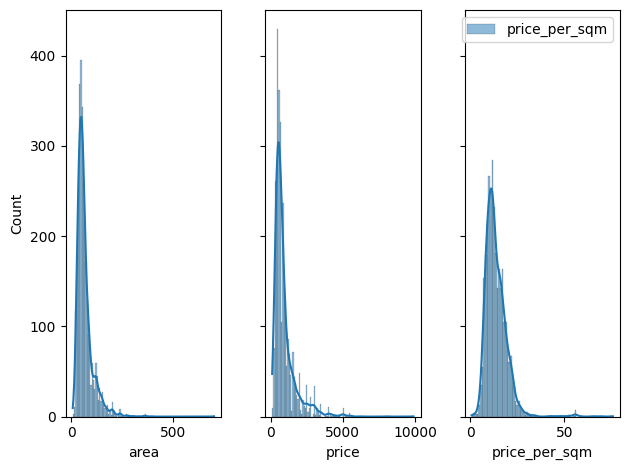

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True)
for ax, col in zip(axes, ["area", "price", "price_per_sqm"]):
    sns.histplot(
        df[col],
        ax=ax,
        label=col,
        kde=True
    )
ax.legend()
plt.tight_layout()
plt.show()

Calculating IQR and outlier thresholds

In [6]:
area_Q1 = np.quantile(df['area'], 0.25)
area_Q3 = np.quantile(df['area'], 0.75)
area_IQR = area_Q3 - area_Q1
area_low = area_Q1 - area_IQR * 1.5
area_high = area_Q3 + area_IQR * 1.5
print(area_low, area_high)

-11.5 128.5


In [7]:
price_Q1 = np.quantile(df['price'], 0.25)
price_Q3 = np.quantile(df['price'], 0.75)
price_IQR = price_Q3 - price_Q1
price_low = price_Q1 - price_IQR * 1.5
price_high = price_Q3 + price_IQR * 1.5
print(price_low, price_high)

-375.0 1825.0


In [8]:
price_per_sqm_Q1 = np.quantile(df['price_per_sqm'], 0.25)
price_per_sqm_Q3 = np.quantile(df['price_per_sqm'], 0.75)
price_per_sqm_IQR = price_per_sqm_Q3 - price_per_sqm_Q1
price_per_sqm_low = price_per_sqm_Q1 - price_per_sqm_IQR * 1.5
price_per_sqm_high = price_per_sqm_Q3 + price_per_sqm_IQR * 1.5
print(price_per_sqm_low, price_per_sqm_high)

0.3424657534246549 26.09589041095891


In [9]:
# IQR based outliers
outliers_area_condition = ~df["area"].between(area_low, area_high)
outliers_price_condition = ~df["price"].between(price_low, price_high)
outliers_price_per_sqm_condition = ~df["price_per_sqm"].between(price_per_sqm_low, price_per_sqm_high)
outliers_all_condition = outliers_area_condition | outliers_price_condition | outliers_price_per_sqm_condition
print(len(df[outliers_area_condition]), len(df[outliers_price_condition]), len(df[outliers_price_per_sqm_condition]), len(df[outliers_all_condition]))

220 301 59 378


In [10]:
# "common sense" based outliers
outliers_area_condition2 = ~df["area"].between(15, 400)
outliers_price_condition2 = ~df["price"].between(50, 5000)
outliers_price_per_sqm_condition2 = ~df["price_per_sqm"].between(5, 80)
outliers_all_condition2 = outliers_area_condition2 | outliers_price_condition2 | outliers_price_per_sqm_condition2
print(len(df[outliers_area_condition2]), len(df[outliers_price_condition2]), len(df[outliers_price_per_sqm_condition2]), len(df[outliers_all_condition2]))

4 8 19 30


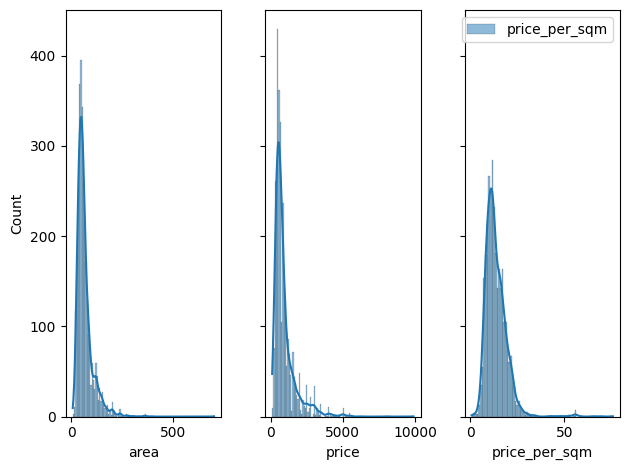

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True)
for ax, col in zip(axes, ["area", "price", "price_per_sqm"]):
    sns.histplot(
        df[col],
        ax=ax,
        label=col,
        kde=True
    )
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# distributions are all right-skewed and IQR outlier detection drops >10% of data
# going with the "common sense" outlier thresholds
df = df[~outliers_all_condition2]
len(df)

3061

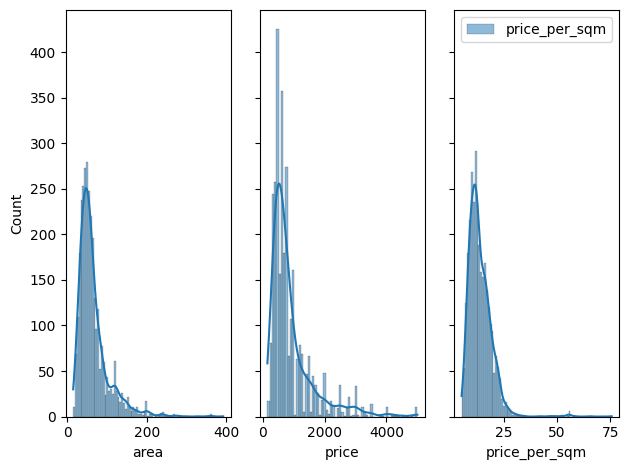

In [13]:
fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True)
for ax, col in zip(axes, ["area", "price", "price_per_sqm"]):
    sns.histplot(
        df[col],
        ax=ax,
        label=col,
        kde=True
    )
ax.legend()
plt.tight_layout()
plt.show()

Transforming area and price to make distributions closer to normal

In [14]:
df["sqrt_area"] = df["area"].pow(1/2)
df["log_price"] = np.log(df["price"])
df["log_price_per_m"] = df["log_price"] / df["sqrt_area"]

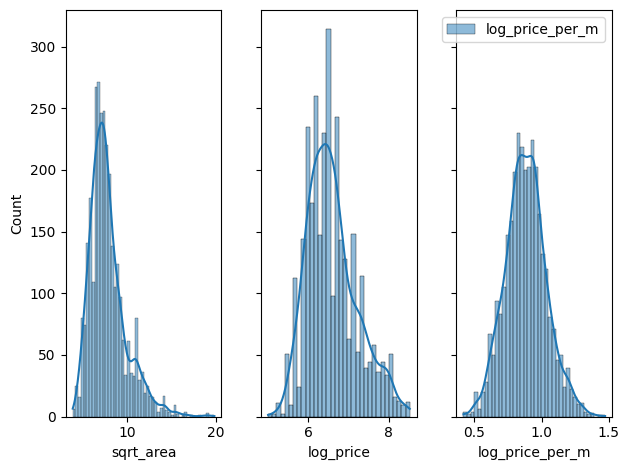

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True)
for ax, col in zip(axes, ["sqrt_area", "log_price", "log_price_per_m"]):
    sns.histplot(
        df[col],
        ax=ax,
        label=col,
        kde=True
    )
ax.legend()
plt.tight_layout()
plt.show()

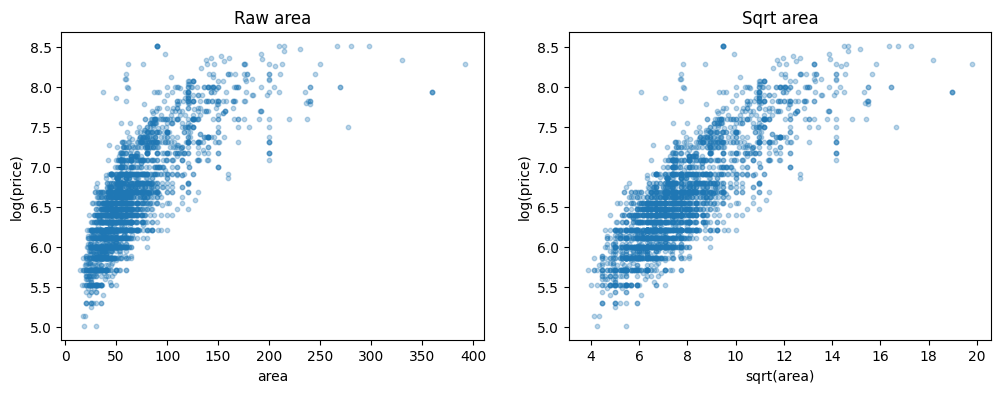

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw area vs log(price)
axes[0].scatter(df["area"], df["log_price"], alpha=0.3, s=10)
axes[0].set(xlabel="area", ylabel="log(price)", title="Raw area")

# Log area vs log(price)
axes[1].scatter(df["sqrt_area"], df["log_price"], alpha=0.3, s=10)
axes[1].set(xlabel="sqrt(area)", ylabel="log(price)", title="Sqrt area")

plt.show()

# Train-test split

Due to the small range of dates, dataset will not be treated as a time-series

In [ ]:
X = df[["floor", "max_floors", "sqrt_area", "rooms", "lat", "lng"]]
y = df["log_price"]
y_binned = pd.qcut(y, q=10, labels=False) # binning target variable to ensure even price groups representation in the training and test splits later

In order to fit a baseline linear model, missing values in the "max_floors" column need to be imputed, or the column needs to be dropped.
Dropping the column here for simplicity.

In [28]:
X_linear = X.drop("max_floors", axis=1)

# Baseline model

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X_linear, y, test_size=0.2, stratify=y_binned)

In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)

In [38]:
from sklearn.metrics import root_mean_squared_error as RMSE, mean_absolute_error as MAE

In [39]:
baseline_rmse = RMSE(y_test, y_pred)
baseline_mae = MAE(y_test, y_pred)
baseline_rmse, baseline_mae

(0.32685798663984644, 0.2633574976760128)

In [40]:
baseline_rmse_exp = RMSE(np.exp(y_test), np.exp(y_pred))
baseline_mae_exp = MAE(np.exp(y_test), np.exp(y_pred))
baseline_rmse_exp, baseline_mae_exp

(504.0158844914182, 264.42188684354966)

# XGBoost model training

In [22]:
from xgboost import XGBRegressor, plot_tree

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y_binned, random_state=42)

In [65]:
model = XGBRegressor(tree_method="hist", early_stopping_rounds=2)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)])

[0]	validation_0-rmse:0.49577
[1]	validation_0-rmse:0.40454
[2]	validation_0-rmse:0.34312
[3]	validation_0-rmse:0.30479
[4]	validation_0-rmse:0.28041
[5]	validation_0-rmse:0.26366
[6]	validation_0-rmse:0.25466


[7]	validation_0-rmse:0.24784
[8]	validation_0-rmse:0.24225
[9]	validation_0-rmse:0.23928
[10]	validation_0-rmse:0.23899
[11]	validation_0-rmse:0.23579
[12]	validation_0-rmse:0.23469
[13]	validation_0-rmse:0.23280
[14]	validation_0-rmse:0.23178
[15]	validation_0-rmse:0.23125
[16]	validation_0-rmse:0.23023
[17]	validation_0-rmse:0.23010
[18]	validation_0-rmse:0.22960
[19]	validation_0-rmse:0.22889
[20]	validation_0-rmse:0.22875
[21]	validation_0-rmse:0.22840
[22]	validation_0-rmse:0.22827
[23]	validation_0-rmse:0.22743
[24]	validation_0-rmse:0.22744
[25]	validation_0-rmse:0.22690
[26]	validation_0-rmse:0.22643
[27]	validation_0-rmse:0.22646
[28]	validation_0-rmse:0.22667


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",2
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [66]:
y_pred = model.predict(X_test)
xgboost_mae = MAE(y_test, y_pred)
xgboost_mae

0.17525539969905682

In [67]:
xgboost_rmse_exp = RMSE(np.exp(y_test), np.exp(y_pred))
xgboost_mae_exp = MAE(np.exp(y_test), np.exp(y_pred))
xgboost_rmse_exp, xgboost_mae_exp

(282.0481192513229, 165.31924978632716)

In [68]:
y_comparison = list(zip(np.exp(y_test[:10]), np.exp(y_pred[:10])))
y_comparison

[(499.99999999999983, np.float32(468.3108)),
 (450.00000000000006, np.float32(422.54086)),
 (600.0, np.float32(1056.0101)),
 (259.99999999999994, np.float32(250.98067)),
 (499.99999999999983, np.float32(632.975)),
 (450.00000000000006, np.float32(838.7756)),
 (600.0, np.float32(630.60315)),
 (349.9999999999999, np.float32(444.5072)),
 (990.0000000000001, np.float32(671.5198)),
 (2250.0000000000005, np.float32(1630.6566))]

# Hyperparameter tuning

Not using target binning here because Scikit-learn's StratifiedKFold only works with classification, would need to implement custom KFold splitter for stratified regression

In [72]:
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score

Finding the optimal number of estimators with a fixed learning rate first, since those parameters are tightly coupled

In [91]:
model = XGBRegressor(learning_rate = 0.05, early_stopping_rounds=50, eval_metric="rmse")
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
best_n = model.best_iteration
best_n

99

In [95]:
model = XGBRegressor()
kf = KFold(n_splits=3, shuffle=True, random_state=42)
param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.05, 0.1, 0.3],
    'max_depth': [5, 7, 10],
    'colsample_bytree': [0.5, 0.75, 1.0],
    'min_child_weight': [1, 3, 5]
}
model_cv = GridSearchCV(model, param_grid=param_grid, cv=kf, n_jobs=-1, scoring="neg_root_mean_squared_error")
model_cv.fit(X_train, y_train)
best_params = model_cv.best_params_
best_score = model_cv.best_score_
best_model = model_cv.best_estimator_

In [96]:
best_params

{'colsample_bytree': 0.5,
 'learning_rate': 0.1,
 'max_depth': 7,
 'min_child_weight': 3,
 'n_estimators': 100}

In [94]:
best_score

np.float64(-0.2353501103505603)

In [97]:
model_best = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=7, 
    min_child_weight=3, 
    colsample_bytree=0.5, 
    early_stopping_rounds=50, 
    eval_metric="rmse"
)
model_best.fit(X_train, y_train, eval_set=[(X_test, y_test)])

[0]	validation_0-rmse:0.58837
[1]	validation_0-rmse:0.54925
[2]	validation_0-rmse:0.51145
[3]	validation_0-rmse:0.47760
[4]	validation_0-rmse:0.45263
[5]	validation_0-rmse:0.43355
[6]	validation_0-rmse:0.41214
[7]	validation_0-rmse:0.39087
[8]	validation_0-rmse:0.37914
[9]	validation_0-rmse:0.35975
[10]	validation_0-rmse:0.34206
[11]	validation_0-rmse:0.32844
[12]	validation_0-rmse:0.31541
[13]	validation_0-rmse:0.30528
[14]	validation_0-rmse:0.29751
[15]	validation_0-rmse:0.29107
[16]	validation_0-rmse:0.28546
[17]	validation_0-rmse:0.27957
[18]	validation_0-rmse:0.27356
[19]	validation_0-rmse:0.26829
[20]	validation_0-rmse:0.26374
[21]	validation_0-rmse:0.26012
[22]	validation_0-rmse:0.25727
[23]	validation_0-rmse:0.25411
[24]	validation_0-rmse:0.25212
[25]	validation_0-rmse:0.25003
[26]	validation_0-rmse:0.24780
[27]	validation_0-rmse:0.24588
[28]	validation_0-rmse:0.24364
[29]	validation_0-rmse:0.24224
[30]	validation_0-rmse:0.24079
[31]	validation_0-rmse:0.23961
[32]	validation_0-

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.5
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'rmse'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [98]:
y_pred = best_model.predict(X_test)
best_rmse = RMSE(y_test, y_pred)
best_mae = MAE(y_test, y_pred)
best_rmse_exp = RMSE(np.exp(y_test), np.exp(y_pred))
best_mae_exp = MAE(np.exp(y_test), np.exp(y_pred))

best_rmse, best_mae, best_rmse_exp, best_mae_exp

(0.2271967636430186,
 0.17559596017762244,
 283.65909426628815,
 168.67287889390357)

Results didn't improve much after hyperparameter tuning, suggesting that this is the maximum obtainable performance given the dataset.

To get better results, additional features such as amenities, building type, etc. would have to be scraped.